In [93]:
import requests
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import Draw
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import numpy as np

from sklearn.linear_model import Ridge


In [25]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 5.3 MB/s  0:00:07a 0:00:010:00:01:01


In [3]:
import requests
import os

doi = "doi:10.7910/DVN/OVHAW8"

meta_url = (
    f"https://dataverse.harvard.edu/api/datasets/:persistentId/"
    f"?persistentId={doi}"
)

dados = requests.get(meta_url).json()

for arq in dados["data"]["latestVersion"]["files"]:

    file_id = arq["dataFile"]["id"]
    nome = arq["dataFile"]["filename"]

    download_url = (
        f"https://dataverse.harvard.edu/api/access/datafile/{file_id}"
    )

    print("baixando", nome)

    conteudo = requests.get(download_url)

    with open(nome, "wb") as f:
        f.write(conteudo.content)

baixando curated-solubility-dataset.tab


In [6]:
import pandas as pd

df = pd.read_csv('curated-solubility-dataset.tab', sep='\t')

In [23]:
df.shape

(9982, 26)

In [14]:
df.columns

Index(['ID', 'Name', 'InChI', 'InChIKey', 'SMILES', 'Solubility', 'SD',
       'Ocurrences', 'Group', 'MolWt', 'MolLogP', 'MolMR', 'HeavyAtomCount',
       'NumHAcceptors', 'NumHDonors', 'NumHeteroatoms', 'NumRotatableBonds',
       'NumValenceElectrons', 'NumAromaticRings', 'NumSaturatedRings',
       'NumAliphaticRings', 'RingCount', 'TPSA', 'LabuteASA', 'BalabanJ',
       'BertzCT'],
      dtype='object')

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9982 entries, 0 to 9981
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   9982 non-null   object 
 1   Name                 9982 non-null   object 
 2   InChI                9982 non-null   object 
 3   InChIKey             9982 non-null   object 
 4   SMILES               9982 non-null   object 
 5   Solubility           9982 non-null   float64
 6   SD                   9982 non-null   float64
 7   Ocurrences           9982 non-null   int64  
 8   Group                9982 non-null   object 
 9   MolWt                9982 non-null   float64
 10  MolLogP              9982 non-null   float64
 11  MolMR                9982 non-null   float64
 12  HeavyAtomCount       9982 non-null   float64
 13  NumHAcceptors        9982 non-null   float64
 14  NumHDonors           9982 non-null   float64
 15  NumHeteroatoms       9982 non-null   f

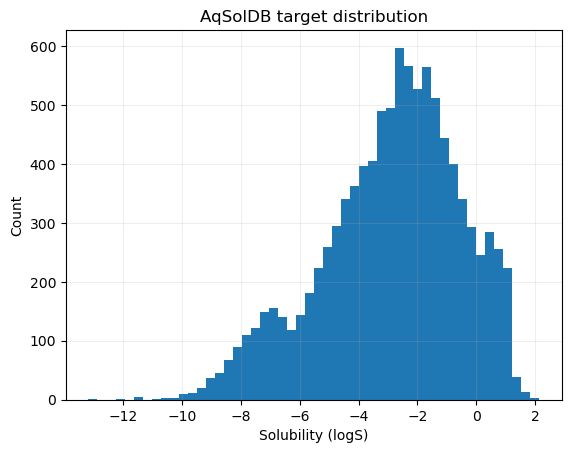

In [35]:
plt.hist(df['Solubility'], bins=50)
plt.xlabel('Solubility (logS)')
plt.ylabel('Count')
plt.grid(alpha=0.2)
plt.title('AqSolDB target distribution')
plt.show()

In [38]:

def smiles_to_mol(s):
    if pd.isna(s):
        return None
    return Chem.MolFromSmiles(s)

df['mol'] = df['SMILES'].map(smiles_to_mol)
bad = df['mol'].isna().sum()
len_df = len(df)
bad, len_df



[17:03:10] WARNING: not removing hydrogen atom without neighbors
[17:03:10] WARNING: not removing hydrogen atom without neighbors
[17:03:10] WARNING: not removing hydrogen atom without neighbors
[17:03:10] WARNING: not removing hydrogen atom without neighbors
[17:03:10] WARNING: not removing hydrogen atom without neighbors
[17:03:10] WARNING: not removing hydrogen atom without neighbors
[17:03:10] WARNING: not removing hydrogen atom without neighbors
[17:03:10] WARNING: not removing hydrogen atom without neighbors
[17:03:10] WARNING: not removing hydrogen atom without neighbors
[17:03:10] WARNING: not removing hydrogen atom without neighbors
[17:03:10] WARNING: not removing hydrogen atom without neighbors
[17:03:10] WARNING: not removing hydrogen atom without neighbors
[17:03:10] WARNING: not removing hydrogen atom without neighbors
[17:03:10] WARNING: not removing hydrogen atom without neighbors
[17:03:10] WARNING: not removing hydrogen atom without neighbors
[17:03:10] WARNING: not r

(np.int64(2), 9982)

In [41]:
df2 = df.dropna(subset=['mol']).copy()
df2.shape

(9980, 27)

In [51]:
df2

,ID,Name,InChI,InChIKey,SMILES,Solubility,SD,Ocurrences,Group,MolWt,...,NumValenceElectrons,NumAromaticRings,NumSaturatedRings,NumAliphaticRings,RingCount,TPSA,LabuteASA,BalabanJ,BertzCT,mol
0,A-3,"N,N,N-trimethyloctadecan-1-aminium bromide",InChI=1S/C21H46N.BrH/c1-5-6-7-8-9-10-11-12-13-...,SZEMGTQCPRNXEG-UHFFFAOYSA-M,[Br-].CCCCCCCCCCCCCCCCCC[N+](C)(C)C,-3.616127,0.000000,1,G1,392.510,...,142.0,0.0,0.0,0.0,0.0,0.00,158.520601,0.000000e+00,210.377334,<rdkit.Chem.rdchem.Mol object at 0x7fc815c6f5a0>
1,A-4,Benzo[cd]indol-2(1H)-one,InChI=1S/C11H7NO/c13-11-8-5-1-3-7-4-2-6-9(12-1...,GPYLCFQEKPUWLD-UHFFFAOYSA-N,O=C1Nc2cccc3cccc1c23,-3.254767,0.000000,1,G1,169.183,...,62.0,2.0,0.0,1.0,3.0,29.10,75.183563,2.582996e+00,511.229248,<rdkit.Chem.rdchem.Mol object at 0x7fc81519ad50>
2,A-5,4-chlorobenzaldehyde,InChI=1S/C7H5ClO/c8-7-3-1-6(5-9)2-4-7/h1-5H,AVPYQKSLYISFPO-UHFFFAOYSA-N,Clc1ccc(C=O)cc1,-2.177078,0.000000,1,G1,140.569,...,46.0,1.0,0.0,0.0,1.0,17.07,58.261134,3.009782e+00,202.661065,<rdkit.Chem.rdchem.Mol object at 0x7fc81519b220>
3,A-8,"zinc bis[2-hydroxy-3,5-bis(1-phenylethyl)benzo...",InChI=1S/2C23H22O3.Zn/c2*1-15(17-9-5-3-6-10-17...,XTUPUYCJWKHGSW-UHFFFAOYSA-L,[Zn++].CC(c1ccccc1)c2cc(C(C)c3ccccc3)c(O)c(c2)...,-3.924409,0.000000,1,G1,756.226,...,264.0,6.0,0.0,0.0,6.0,120.72,323.755434,2.322963e-07,1964.648666,<rdkit.Chem.rdchem.Mol object at 0x7fc81519a8f0>
4,A-9,4-({4-[bis(oxiran-2-ylmethyl)amino]phenyl}meth...,InChI=1S/C25H30N2O4/c1-5-20(26(10-22-14-28-22)...,FAUAZXVRLVIARB-UHFFFAOYSA-N,C1OC1CN(CC2CO2)c3ccc(Cc4ccc(cc4)N(CC5CO5)CC6CO...,-4.662065,0.000000,1,G1,422.525,...,164.0,2.0,4.0,4.0,6.0,56.60,183.183268,1.084427e+00,769.899934,<rdkit.Chem.rdchem.Mol object at 0x7fc81519ac70>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9977,I-84,tetracaine,InChI=1S/C15H24N2O2/c1-4-5-10-16-14-8-6-13(7-9...,GKCBAIGFKIBETG-UHFFFAOYSA-N,C(c1ccc(cc1)NCCCC)(=O)OCCN(C)C,-3.010000,0.000000,1,G1,264.369,...,106.0,1.0,0.0,0.0,1.0,41.57,115.300645,2.394548e+00,374.236893,<rdkit.Chem.rdchem.Mol object at 0x7fc810947ae0>
9978,I-85,tetracycline,InChI=1S/C22H24N2O8/c1-21(31)8-5-4-6-11(25)12(...,OFVLGDICTFRJMM-WESIUVDSSA-N,OC1=C(C(C2=C(O)[C@@](C(C(C(N)=O)=C(O)[C@H]3N(C...,-2.930000,0.000000,1,G1,444.440,...,170.0,1.0,0.0,3.0,4.0,181.62,182.429237,2.047922e+00,1148.584975,<rdkit.Chem.rdchem.Mol object at 0x7fc810947b50>
9979,I-86,thymol,InChI=1S/C10H14O/c1-7(2)9-5-4-8(3)6-10(9)11/h4...,MGSRCZKZVOBKFT-UHFFFAOYSA-N,c1(cc(ccc1C(C)C)C)O,-2.190000,0.019222,3,G5,150.221,...,60.0,1.0,0.0,0.0,1.0,20.23,67.685405,3.092720e+00,251.049732,<rdkit.Chem.rdchem.Mol object at 0x7fc810947bc0>
9980,I-93,verapamil,"InChI=1S/C27H38N2O4/c1-20(2)27(19-28,22-10-12-...",SGTNSNPWRIOYBX-UHFFFAOYSA-N,COc1ccc(CCN(C)CCCC(C#N)(C(C)C)c2ccc(OC)c(OC)c2...,-3.980000,0.000000,1,G1,454.611,...,180.0,2.0,0.0,0.0,2.0,63.95,198.569223,2.023333e+00,938.203977,<rdkit.Chem.rdchem.Mol object at 0x7fc810947c30>


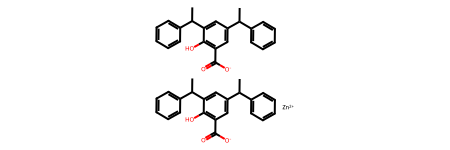

In [49]:
df['mol'][3]

In [103]:


identity_columns = ["ID", "Name", "InChI", "InChIKey", "SMILES"]

target_column = "Solubility"

metadata_columns = ["SD", "Ocurrences", "Group"]

descriptor_columns = [
    "MolWt",
    "MolLogP",
    "MolMR",
    "HeavyAtomCount",
    "NumHAcceptors",
    "NumHDonors",
    "NumHeteroatoms",
    "NumRotatableBonds",
    "NumValenceElectrons",
    "NumAromaticRings",
    "NumSaturatedRings",
    "NumAliphaticRings",
    "RingCount",
    "TPSA",
    "LabuteASA",
    "BalabanJ",
    "BertzCT"
]

delaney_features = ['MolLogP', 'MolWt', 'NumRotatableBonds', 'NumHDonors']


<Axes: >

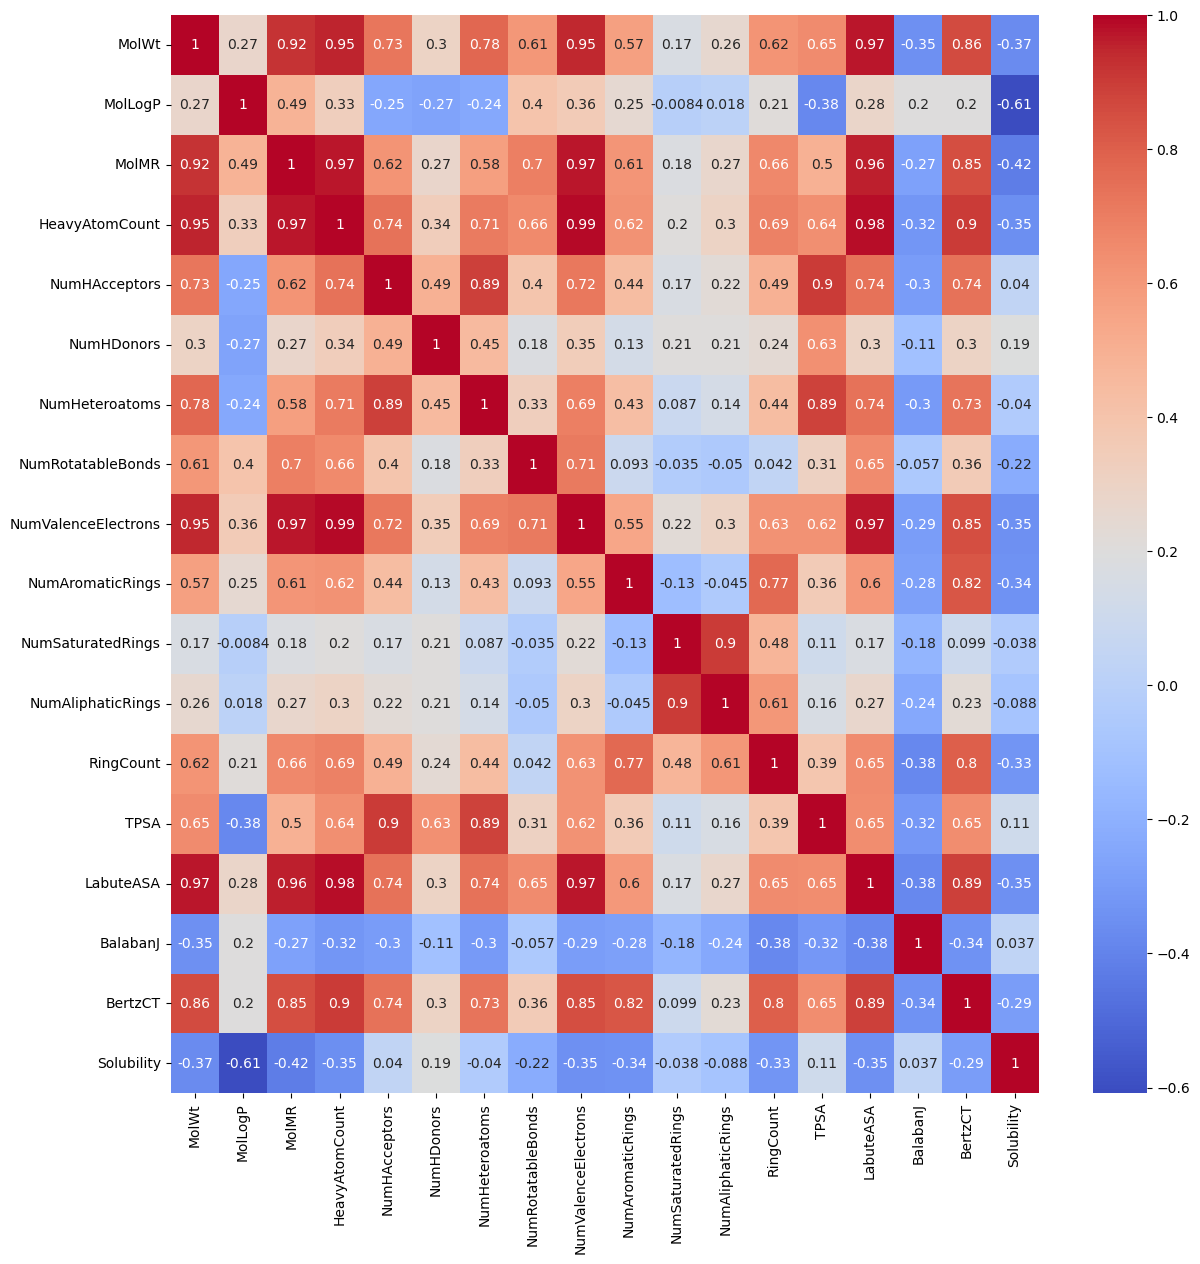

In [66]:
teste = df[descriptor_columns].corr()
plt.figure(figsize=(14,14))
sns.heatmap(teste, annot=True, cmap='coolwarm')

In [88]:
df[descriptor_columns]

,MolWt,MolLogP,NumHAcceptors,NumHDonors,NumHeteroatoms,NumRotatableBonds,NumAromaticRings,NumSaturatedRings,NumAliphaticRings,RingCount,TPSA,BalabanJ,BertzCT
0,392.510,3.95810,0.0,0.0,2.0,17.0,0.0,0.0,0.0,0.0,0.00,0.000000e+00,210.377334
1,169.183,2.40550,1.0,1.0,2.0,0.0,2.0,0.0,1.0,3.0,29.10,2.582996e+00,511.229248
2,140.569,2.15250,1.0,0.0,2.0,1.0,1.0,0.0,0.0,1.0,17.07,3.009782e+00,202.661065
3,756.226,8.11610,6.0,2.0,7.0,10.0,6.0,0.0,0.0,6.0,120.72,2.322963e-07,1964.648666
4,422.525,2.48540,6.0,0.0,6.0,12.0,2.0,4.0,4.0,6.0,56.60,1.084427e+00,769.899934
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9977,264.369,2.61700,4.0,1.0,4.0,8.0,1.0,0.0,0.0,1.0,41.57,2.394548e+00,374.236893
9978,444.440,-0.21440,9.0,6.0,10.0,2.0,1.0,0.0,3.0,4.0,181.62,2.047922e+00,1148.584975
9979,150.221,2.82402,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,20.23,3.092720e+00,251.049732
9980,454.611,5.09308,6.0,0.0,6.0,13.0,2.0,0.0,0.0,2.0,63.95,2.023333e+00,938.203977


In [100]:
X = df[descriptor_columns]
y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=2)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
modelo = LinearRegression().fit(X_train_scaled, y_train)

pred_20 = modelo.predict(X_test_scaled)


In [74]:
pred_20

array([-0.65895834, -1.79326629, -4.90179364, ..., -3.13474017,
       -5.30637803, -2.65870186], shape=(1997,))

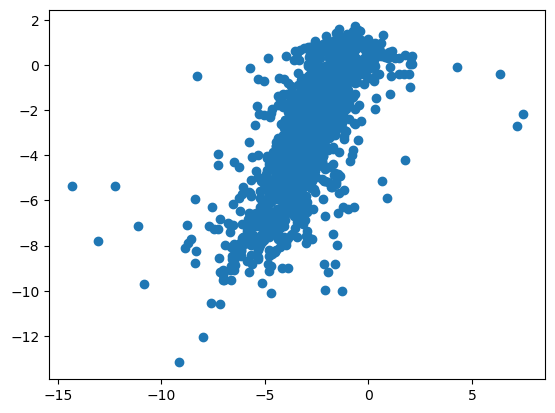

In [90]:
plt.scatter(pred_20, y_test)

In [91]:
print(f"R²:  {r2_score(y_test, pred_20):.4f}")
print(f"MAE: {mean_absolute_error(y_test, pred_20):.4f}")


rmse = np.sqrt(mean_squared_error(y_test, pred_20))
print(f"RMSE: {rmse:.4f}")

R²:  0.5178
MAE: 1.2561
RMSE: 1.6827


In [84]:
import numpy as np

In [95]:
modelo = Ridge(alpha=1.0).fit(X_train_scaled, y_train)

pred_20 = modelo.predict(X_test_scaled)

In [96]:
print(f"R²:  {r2_score(y_test, pred_20):.4f}")
print(f"MAE: {mean_absolute_error(y_test, pred_20):.4f}")


rmse = np.sqrt(mean_squared_error(y_test, pred_20))
print(f"RMSE: {rmse:.4f}")

R²:  0.5178
MAE: 1.2561
RMSE: 1.6826


In [101]:

modelo = Ridge(alpha=1.0).fit(X_train_scaled, y_train)

pred_20 = modelo.predict(X_test_scaled)


print(f"R²:  {r2_score(y_test, pred_20):.4f}")
print(f"MAE: {mean_absolute_error(y_test, pred_20):.4f}")


rmse = np.sqrt(mean_squared_error(y_test, pred_20))
print(f"RMSE: {rmse:.4f}")




R²:  0.5196
MAE: 1.2473
RMSE: 1.6794


In [127]:
from sklearn.ensemble import RandomForestRegressor

X = df[descriptor_columns]
y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=2)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

modelo = RandomForestRegressor(n_estimators=100, random_state=42)
modelo.fit(X_train_scaled, y_train)
pred_20 = modelo.predict(X_test_scaled)

print(f"R²:  {r2_score(y_test, pred_20):.4f}")
print(f"MAE: {mean_absolute_error(y_test, pred_20):.4f}")
rmse = np.sqrt(mean_squared_error(y_test, pred_20))
print(f"RMSE: {rmse:.4f}")

R²:  0.7608
MAE: 0.7952
RMSE: 1.1850


In [115]:
from sklearn.ensemble import GradientBoostingRegressor

modelo = GradientBoostingRegressor(n_estimators=100, random_state=42)
modelo.fit(X_train_scaled, y_train)
pred_20 = modelo.predict(X_test_scaled)

print(f"R²:  {r2_score(y_test, pred_20):.4f}")
print(f"MAE: {mean_absolute_error(y_test, pred_20):.4f}")
rmse = np.sqrt(mean_squared_error(y_test, pred_20))
print(f"RMSE: {rmse:.4f}")

R²:  0.6873
MAE: 0.9678
RMSE: 1.3550


In [116]:
pip install xgboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 21.5 MB/s  0:00:06 eta 0:00:010:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.2/300.2 MB 13.0 MB/s  0:00:21 eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [xgboost]━━━ 1/2 [xgboost]
Note: you may need to restart the kernel to use updated packages.


In [117]:
from xgboost import XGBRegressor

modelo = XGBRegressor(n_estimators=100, random_state=42)
modelo.fit(X_train_scaled, y_train)
pred_20 = modelo.predict(X_test_scaled)

print(f"R²:  {r2_score(y_test, pred_20):.4f}")
print(f"MAE: {mean_absolute_error(y_test, pred_20):.4f}")
rmse = np.sqrt(mean_squared_error(y_test, pred_20))
print(f"RMSE: {rmse:.4f}")

R²:  0.6890
MAE: 0.9462
RMSE: 1.3514


In [118]:
resultados = {
    'Regressão Linear': {'R²': 0.5187, 'MAE': 1.2476, 'RMSE': 1.6810},
    'Ridge':            {'R²': 0.5178, 'MAE': 1.2561, 'RMSE': 1.6826},
    'Gradient Boosting':{'R²': 0.6873, 'MAE': 0.9678, 'RMSE': 1.3550},
    'XGBoost':          {'R²': 0.6890, 'MAE': 0.9462, 'RMSE': 1.3514},
    'Random Forest':    {'R²': 0.7608, 'MAE': 0.7952, 'RMSE': 1.1850},
}

df_resultados = pd.DataFrame(resultados).T
print(df_resultados)

                       R²     MAE    RMSE
Regressão Linear   0.5187  1.2476  1.6810
Ridge              0.5178  1.2561  1.6826
Gradient Boosting  0.6873  0.9678  1.3550
XGBoost            0.6890  0.9462  1.3514
Random Forest      0.7608  0.7952  1.1850


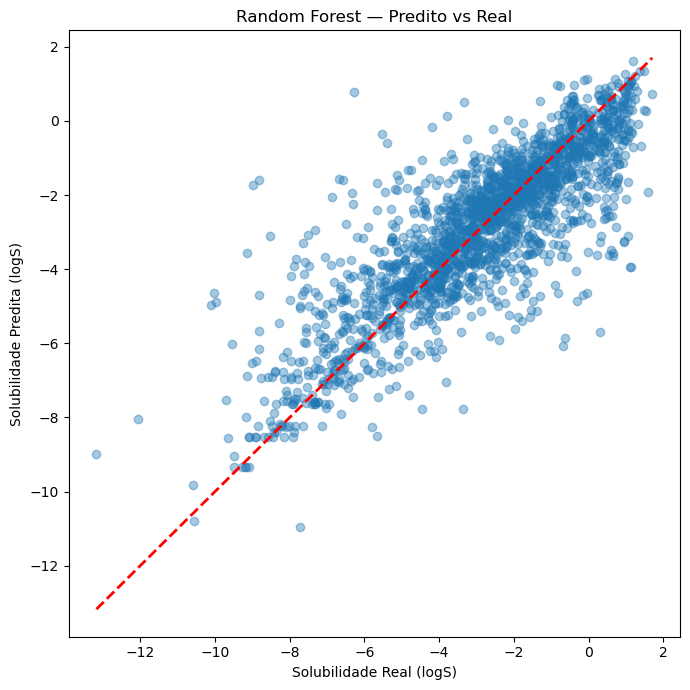

In [119]:
plt.figure(figsize=(7,7))
plt.scatter(y_test, pred_20, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Solubilidade Real (logS)')
plt.ylabel('Solubilidade Predita (logS)')
plt.title('Random Forest — Predito vs Real')
plt.tight_layout()
plt.show()

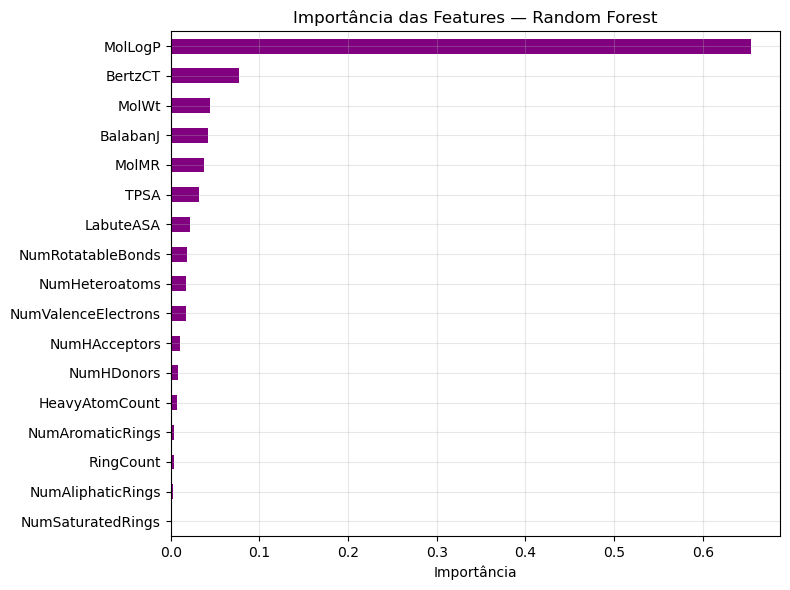

In [128]:
importancias = pd.Series(modelo.feature_importances_, index=descriptor_columns).sort_values()
importancias.plot(kind='barh', figsize=(8,6), color='Purple')
plt.title('Importância das Features — Random Forest')
plt.xlabel('Importância')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [129]:
df['RingFeatures'] = (df['NumAromaticRings'] + df['RingCount'] + 
                      df['NumAliphaticRings'] + df['NumSaturatedRings'])

descriptor_columns_v2 = [c for c in descriptor_columns 
                         if c not in ['NumAromaticRings', 'RingCount', 
                                      'NumAliphaticRings', 'NumSaturatedRings']]
descriptor_columns_v2.append('RingFeatures')

print(f"Features anteriores: {len(descriptor_columns)}")
print(f"Features novas: {len(descriptor_columns_v2)}")

Features anteriores: 17
Features novas: 14


In [130]:
descriptor_columns_v2

['MolWt',
 'MolLogP',
 'MolMR',
 'HeavyAtomCount',
 'NumHAcceptors',
 'NumHDonors',
 'NumHeteroatoms',
 'NumRotatableBonds',
 'NumValenceElectrons',
 'TPSA',
 'LabuteASA',
 'BalabanJ',
 'BertzCT',
 'RingFeatures']

In [134]:
from sklearn.ensemble import RandomForestRegressor

X = df[descriptor_columns_v2]
y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=2)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

modelo = RandomForestRegressor(n_estimators=100, random_state=42)
modelo.fit(X_train_scaled, y_train)
pred_20 = modelo.predict(X_test_scaled)

print(f"R²:  {r2_score(y_test, pred_20):.4f}")
print(f"MAE: {mean_absolute_error(y_test, pred_20):.4f}")
rmse = np.sqrt(mean_squared_error(y_test, pred_20))
print(f"RMSE: {rmse:.4f}")

R²:  0.7602
MAE: 0.7968
RMSE: 1.1866


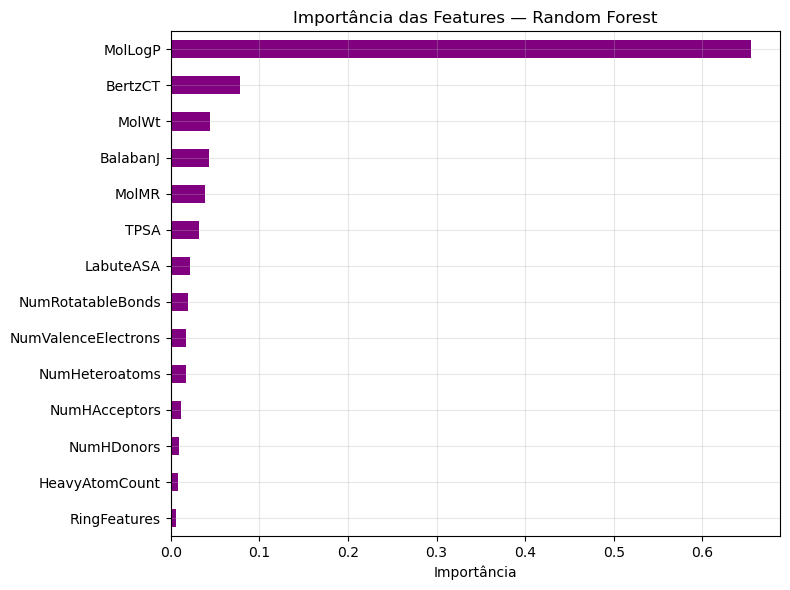

In [135]:
importancias = pd.Series(modelo.feature_importances_, index=descriptor_columns_v2).sort_values()
importancias.plot(kind='barh', figsize=(8,6), color='Purple')
plt.title('Importância das Features — Random Forest')
plt.xlabel('Importância')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Essa importancia muito superior de MolLogP é esperada pois essa grandeza é calculada como medida da lipofilicidade da molécula. O modelo captura essa dependendcia principa. O modelo também trás uma importancia para complexidade molecular com BertzCT apresentando segunda maior importância. Isso pode ser estar relacionado que com complexidade maior, maior será a alteração da estrutura de hidrocarboneto, adicionando assim uma alteração nos dipolos das moléculas. A importância 